<h1><center><b>Yolo Object Detection</b></center></h1>

In [ ]:
# yolo: you only look once
# ssd: single short detection
# here we are using yolo3: darknet
# currently we have yolo10 version
# Here i will explain from very scratch
# but yolo10 has package available now: ultralytics

# cfg: configuration file
#      It has model architecture
#      how many layers
#      how many convolution
#      batch size/learning rate/ optimizer

# It is Transfer learning, we are not developing the model from scratch

# weight file:
#     after develop the model we have weight file

# coco: is a dataset name on which the model devloped
# coco.names files: there are 80 classes

https://github.com/pjreddie/darknet/blob/master/cfg/yolov3-tiny.cfg

<img src="https://www.researchgate.net/publication/350502286/figure/fig2/AS:1007224067473409@1617152339116/YOLOv3-architecture.ppm" jsaction="VQAsE" class="sFlh5c pT0Scc iPVvYb" style="max-width: 850px; height: 110px; margin: 14.5px 0px; width: 351px;" alt="YOLOv3 architecture. | Download Scientific Diagram" jsname="kn3ccd" aria-hidden="false">

In [ ]:
# custom training: we will finetune exist model using our own data
# We are not training the model
# Your concentartion 
# If you see any code, you need to undestand each and every line

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#cv2.dnn.readNet("./yolov3-tiny.weights","./yolov3-tiny.cfg")

In [3]:
modelConf="C:\\Users\\omkar\\OneDrive\\Documents\\Data science\\Naresh IT\\AI learnings\\Yolo\\files\\yolov3-tiny.cfg"
modelWeights="C:\\Users\\omkar\\OneDrive\\Documents\\Data science\\Naresh IT\\AI learnings\\Yolo\\files\\yolov3-tiny.weights"
net = cv2.dnn.readNetFromDarknet(modelConf,modelWeights)
net

< cv2.dnn.Net 00000238E39C55B0>

In [12]:
import warnings
warnings.filterwarnings('ignore')
modelConf="E:\\Python Projects\\YOLO Model\\Yolo\\files\\yolov3-tiny.cfg"
modelWeights="E:\\Python Projects\\YOLO Model\\Yolo\\files\\yolov3-tiny.weights"
net = cv2.dnn.readNetFromDarknet(modelConf,modelWeights)
net

< cv2.dnn.Net 0000025396A1D5F0>

In [92]:
classesFile="coco.names"
file=open(classesFile,'rt')
file.read()

'person\nbicycle\ncar\nmotorbike\naeroplane\nbus\ntrain\ntruck\nboat\ntraffic light\nfire hydrant\nstop sign\nparking meter\nbench\nbird\ncat\ndog\nhorse\nsheep\ncow\nelephant\nbear\nzebra\ngiraffe\nbackpack\numbrella\nhandbag\ntie\nsuitcase\nfrisbee\nskis\nsnowboard\nsports ball\nkite\nbaseball bat\nbaseball glove\nskateboard\nsurfboard\ntennis racket\nbottle\nwine glass\ncup\nfork\nknife\nspoon\nbowl\nbanana\napple\nsandwich\norange\nbroccoli\ncarrot\nhot dog\npizza\ndonut\ncake\nchair\nsofa\npottedplant\nbed\ndiningtable\ntoilet\ntvmonitor\nlaptop\nmouse\nremote\nkeyboard\ncell phone\nmicrowave\noven\ntoaster\nsink\nrefrigerator\nbook\nclock\nvase\nscissors\nteddy bear\nhair drier\ntoothbrush\n'

In [14]:
classesFile="coco.names"
with open(classesFile,'rt') as f:
    classes = f.read().rstrip('\n').split('\n')
classes

['person',
 'bicycle',
 'car',
 'motorbike',
 'aeroplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'sofa',
 'pottedplant',
 'bed',
 'diningtable',
 'toilet',
 'tvmonitor',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush']

In [16]:
len(classes) # number of classes

80

In [94]:
net # model variable name is net

< cv2.dnn.Net 0000025396A1D5F0>

In [96]:
dir(net)

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'addLayer',
 'addLayerToPrev',
 'connect',
 'dump',
 'dumpToFile',
 'dumpToPbtxt',
 'empty',
 'enableFusion',
 'enableWinograd',
 'forward',
 'forwardAndRetrieve',
 'forwardAsync',
 'getFLOPS',
 'getInputDetails',
 'getLayer',
 'getLayerId',
 'getLayerNames',
 'getLayerTypes',
 'getLayersCount',
 'getLayersShapes',
 'getMemoryConsumption',
 'getOutputDetails',
 'getParam',
 'getPerfProfile',
 'getUnconnectedOutLayers',
 'getUnconnectedOutLayersNames',
 'quantize',
 'readFromModelOptimizer',
 'registerOutput',
 'setHalideScheduler',
 'setInput',
 'setInputShape',
 'setInputsNames',
 'setParam',
 'setPreferableBackend',
 'setPreferable

In [18]:
l=net.getLayerNames()  # number of layers
len(l)

48

In [98]:
print(l[:5])

('conv_0', 'bn_0', 'leaky_1', 'pool_1', 'conv_2')


In [20]:
l

('conv_0',
 'bn_0',
 'leaky_1',
 'pool_1',
 'conv_2',
 'bn_2',
 'leaky_3',
 'pool_3',
 'conv_4',
 'bn_4',
 'leaky_5',
 'pool_5',
 'conv_6',
 'bn_6',
 'leaky_7',
 'pool_7',
 'conv_8',
 'bn_8',
 'leaky_9',
 'pool_9',
 'conv_10',
 'bn_10',
 'leaky_11',
 'pool_11',
 'conv_12',
 'bn_12',
 'leaky_13',
 'conv_13',
 'bn_13',
 'leaky_14',
 'conv_14',
 'bn_14',
 'leaky_15',
 'conv_15',
 'permute_16',
 'yolo_16',
 'identity_17',
 'conv_18',
 'bn_18',
 'leaky_19',
 'upsample_19',
 'concat_20',
 'conv_21',
 'bn_21',
 'leaky_22',
 'conv_22',
 'permute_23',
 'yolo_23')

In [22]:
l1=net.getUnconnectedOutLayers()  # yolo layers indexes
l1

array([36, 48])

In [24]:
l[35],l[47]

('yolo_16', 'yolo_23')

In [26]:
l2=net.getUnconnectedOutLayersNames() # yolo layers names
l2

('yolo_16', 'yolo_23')

In [100]:
net.getInputDetails

<function Net.getInputDetails>

### blobfromImage() function

It returns a 4-dimensional array/blob for the input image. 
You can additionally use it to preprocess your image to match your input requirements. 
You can use its different parameters to transform your image, 

so let’s discuss all its parameters: 
    
**image**

- This is the image that we want to preprocess (for our model)
    
**scalefactor**

- scale factor basically multiplies(scales) our image channels. And remember that it scales it down by a factor of 1/n, where n is the scalefactor you provided.

**size**

- this is the target size that we want our image to become. Most common CNNs use 224×224 or 229×229 pixels as their input image array, but you can set it to meet your model requirements.

**mean**

- this is the mean subtracting values. You can input a single value or a 3-item tuple for each channel RGB, it will basically subtract the mean value from all the channels accordingly, this is done to normalize our pixel values. Note: mean argument utilizes the RGB sequence

**swapRB**

   - OpenCV by default reads an image in BGR format, but as I mentioned above that the mean argument takes in the values in RGB sequence, so to prevent any disruption this function, as the name implies swaps the red and blue channels. ( i.e why its default value is True)

In [28]:
# reshape the image
inpWidth = 416
inpHeight = 416
frame=cv2.imread('./images/dog.jpg')
# generally image will take as BGR we need to change RGB
blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], 1, crop = False) # pass the image

In [102]:
blob.dtype
# 32 bit is the depth of pxel

dtype('float32')

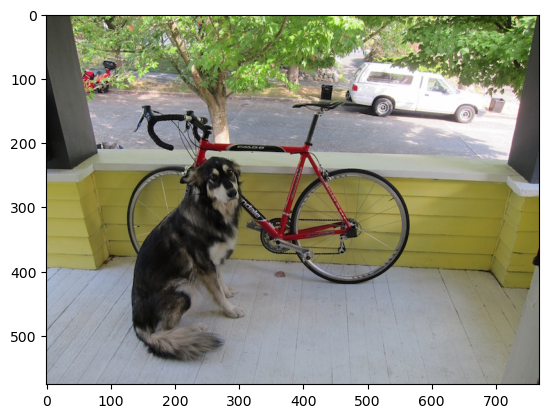

In [30]:
# Change BGR to RGB
img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
plt.imshow(img)

In [104]:
frame.shape   # origianl shape

(576, 768, 3)

In [106]:
blob.shape # blob will take in revrseba
# (batch,channels,he,w)

(1, 3, 416, 416)

In [108]:
blob[0].shape

(3, 416, 416)

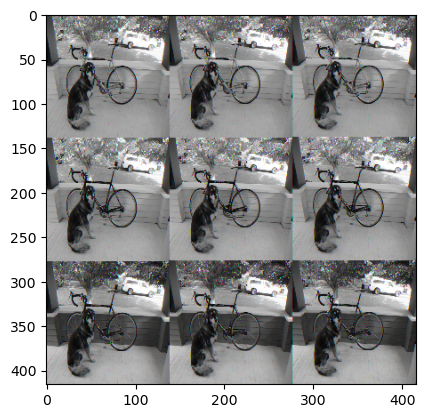

In [110]:
im=blob[0].reshape(416,416,3)
plt.imshow(im)

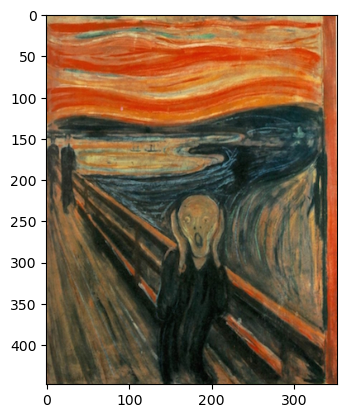

In [32]:
# reshape the image
inpWidth = 416
inpHeight = 416
frame=cv2.imread('./images/scream.jpg')
# generally image will take as BGR we need to change RGB
blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], 1, crop = False) # pass the image

# Change BGR to RGB
img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
plt.imshow(img)

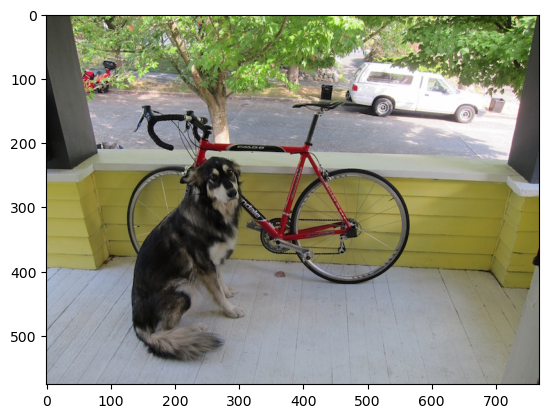

In [34]:
# reshape the image
inpWidth = 416
inpHeight = 416
frame=cv2.imread('./images/dog.jpg')
# generally image will take as BGR we need to change RGB
blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], 1, crop = False) # pass the image

# Change BGR to RGB
img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
plt.imshow(img)

In [36]:
frame.shape

(576, 768, 3)

In [38]:
blob.shape # blob will take in revrse

(1, 3, 416, 416)

In [40]:
blob[0].shape

(3, 416, 416)

In [44]:
#im=blob[0].reshape(416,416,3)
#plt.imshow(im)

net.setInput(blob)

In [46]:
yolo_layers=net.getUnconnectedOutLayersNames()
outs = net.forward(yolo_layers)
outs
# there two yolo layers are there
# in image two objects are there
# we have toatal 80 classes are there
# we got 85 values 5+80
# 5 means  x,y,w,h,confidance
# 80 mean probability of each class

(array([[0.04629856, 0.04855685, 0.20454988, ..., 0.        , 0.        ,
         0.        ],
        [0.03691919, 0.05203305, 0.14872797, ..., 0.        , 0.        ,
         0.        ],
        [0.03360242, 0.0461693 , 0.76369286, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.95248353, 0.963941  , 0.1911617 , ..., 0.        , 0.        ,
         0.        ],
        [0.9570926 , 0.95338863, 0.1868322 , ..., 0.        , 0.        ,
         0.        ],
        [0.9686857 , 0.9525847 , 0.7930905 , ..., 0.        , 0.        ,
         0.        ]], dtype=float32),
 array([[0.01915744, 0.01699508, 0.03062352, ..., 0.        , 0.        ,
         0.        ],
        [0.02472977, 0.02360389, 0.04224724, ..., 0.        , 0.        ,
         0.        ],
        [0.01501428, 0.0198308 , 0.11940214, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.97540367, 0.9773502 , 0.02305205, ..., 0.        , 0.        ,
         0.        

In [48]:
len(outs) # two objects output

2

In [50]:
len(outs[0]) # model is identifies total 507 boxes and predictins

#5+80 
# first 5 values are the  x,y,w,h and confidence for the first box
# remaining 80 are the classes

507

In [52]:
len(outs[1])

2028

In [54]:
len(outs[0][1]),len(outs[1][0])

(85, 85)

In [56]:
len(outs[0][0])  # 85 values

85

In [58]:
list(outs[0][0])[:5]

[0.04629856, 0.048556846, 0.20454988, 0.17124683, 5.54704e-06]

In [60]:
list(outs[0][0])[5:]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [62]:
outs[0][5]

array([1.1806286e-01, 5.0466016e-02, 6.5351522e-01, 6.7961854e-01,
       1.7038695e-07, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e

**Detect the Bounding Boxes**

Those are what are called normalized coordinates. 

To get the width in pixels you would need to multiply by the width of the images

In [66]:
frameHeight = frame.shape[0] # Original image 576
frameWidth = frame.shape[1] # 768
boxes=[]
confidences=[]
classIDs=[]
for out in outs: # calling each object boxes 2 times
    for detection in out: # calling each box len(outs[0])=507 ; len(outs[1])=2028
        score=detection[5:] # probability of 80 classes
        class_id=np.argmax(score) # max probability id
        confidence=score[class_id] # getting the confidance
        if confidence>0.7:         # if confidance >70% consider as that is valid bounding box
            print(detection)
            centerX = int(detection[0] * frameWidth)  # before we pass the object we divided with frame width
            # these are the normalized values so multiply again
            centerY = int(detection[1] * frameHeight)
            width = int(detection[2]* frameWidth)
            height = int(detection[3]*frameHeight )
            left = int(centerX - width/2)
            top = int(centerY - height/2)

            classIDs.append(class_id)
            confidences.append(float(confidence))
            boxes.append([left, top, width, height])
            
boxes

[0.7506749  0.22071587 0.28650168 0.15503979 0.95903397 0.
 0.         0.72524565 0.         0.         0.         0.
 0.39470446 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        ]
[0.3298957  0.64003456 0.33577326 0.520143   0.8333812  0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.       

[[466, 82, 220, 89], [124, 218, 257, 299]]

In [68]:
len(outs[0]),len(outs[1])

(507, 2028)

In [70]:
507+2028

2535

In [72]:
confidences

[0.7252456545829773, 0.8289406299591064]

**NMS: Non Max suppresion**

## NMS : Non Max Supression

What is Non-Maximum supression (NMS)?

Non-Maximum Suppression (NMS) is a post-processing technique used in  objct detection to eliminate redundant bounding boxes for the same object. When a model predicts multiple overlapping bounding boxes for a single object, NMS ensures that only the most accurate box is kept, effectively reducing noise in the detections.

## Why is NMS needed?

Object detection models, such as YOLO,SSD, or Faster R-CNN, can generate multiple bounding boxes for the same object, especially in overlapping regions. Without NMS these overlapping boxes could clutter making it harder to identify distinct objects. NMS removes these duplicates while retaining the box with the highest confidence score.

## How does NMS work?

The NMS algorithm follow these steps:

- Start with predicting boxes

# Key Parameters :
- Confidence Threshold:
    - Filters out low-confidence detections before applying NMS
- IoU Threshold
- Determines how much overlap is allowed before a box is considered redundant. Common values are in the range of 0.3 - 0.5

IoU : Intersection Of Union

Jaccard Distance :

IoU = Area of Overlap / Area of Union

IOU : Intersection Of Union

# NMS:

In [74]:
indexes=cv2.dnn.NMSBoxes(boxes,confidences,0.5,0.4)
indexes  # surprass many boxes

array([1, 0])

In [76]:
boxes[1],boxes[0]

([124, 218, 257, 299], [466, 82, 220, 89])

# Apply the Bounding Box :

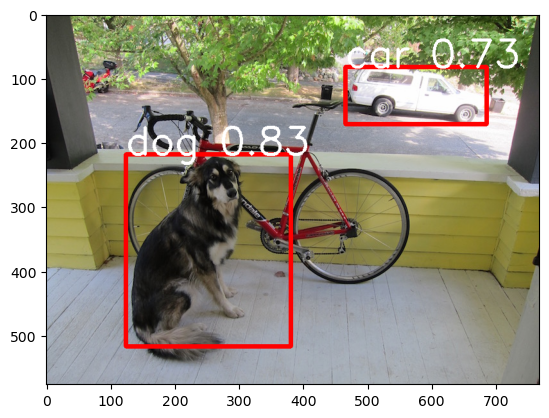

In [80]:
font=cv2.FONT_HERSHEY_SIMPLEX
color=(255,0,0) # RGB
for i in indexes:
    x,y,w,h=boxes[i]
    label=str(classes[classIDs[i]])
    confi=str(round(confidences[i],2))
    #color=colors[i]
    cv2.rectangle(img,(x,y),(x+w,y+h),color,5,i)   # (x,y): left,top     (x+w,y+h): right,bottom
    cv2.putText(img,label +" "+confi,(x,y),font,2,(255,255,255),3)
plt.imshow(img)

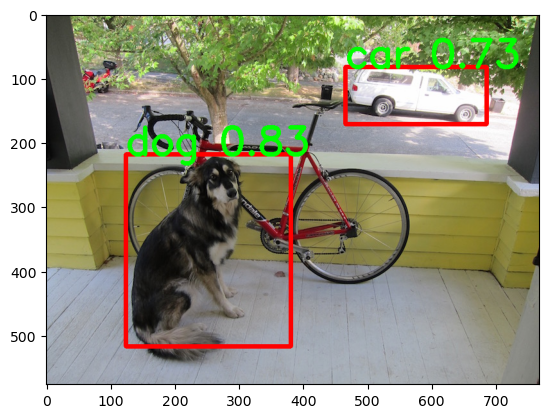

In [129]:
font=cv2.FONT_HERSHEY_SIMPLEX
color=(255,0,0) # RGB
for i in indexes:
    x,y,w,h=boxes[i]
    label=str(classes[classIDs[i]])
    confi=str(round(confidences[i],2))
    cv2.rectangle(img,
                  (x,y),
                  (x+w,y+h),
                  color,
                  5,
                  i)   # (x,y): left,top     (x+w,y+h): right,bottom
    cv2.putText(img,
                label +" "+confi,
                (x,y),
                font,
                2,
                (0,255,0),
                5)
plt.imshow(img)

## Method-1:
    
**Bounding box on images**

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [86]:
def post_process(frame,outs,img,classes): # outs : Output
    frameHeight = frame.shape[0]
    frameWidth = frame.shape[1]
    boxes=[]
    confidences=[]
    classIDs=[]
    for out in outs: # calling each object boxes
        for detection in out: # calling each box
            score=detection[5:] # probability of 80 classes
            class_id=np.argmax(score) # max probability id
            confidence=score[class_id] # getting the confidance
            if confidence>0.7:         # if confidance >70% consider as that is valid bounding box
                centerX = int(detection[0] * frameWidth)  # before we pass the object we divided with frame width
                # these are the normalized values so multiply again
                centerY = int(detection[1] * frameHeight)
                width = int(detection[2]* frameWidth)
                height = int(detection[3]*frameHeight )
                left = int(centerX - width/2)
                top = int(centerY - height/2)
                classIDs.append(class_id)
                confidences.append(float(confidence))
                boxes.append([left, top, width, height])
                
    indexes=cv2.dnn.NMSBoxes(boxes,confidences,0.5,0.4)
    font=cv2.FONT_HERSHEY_SIMPLEX
    color=(255,0,0) # RGB
    for i in indexes:
        x,y,w,h=boxes[i]
        label=str(classes[classIDs[i]])
        confi=str(round(confidences[i],2))
        cv2.rectangle(img,(x,y),(x+w,y+h),color,5,i)   # (x,y): left,top     (x+w,y+h): right,bottom
        cv2.putText(img,label +" "+confi,(x,y),font,2,(255,255,255),3)
    plt.imshow(img)

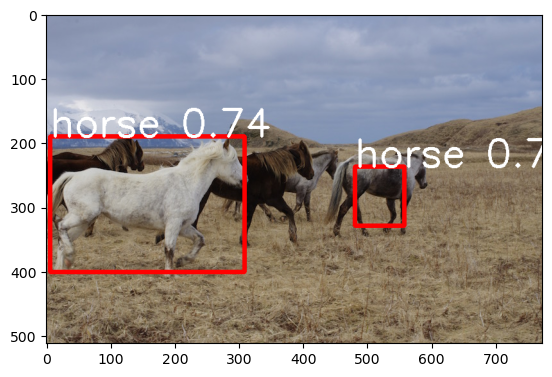

In [88]:
# All at one place
modelConf="yolov3-tiny.cfg"
modelWeights="yolov3-tiny.weights"
classesFile="coco.names"
image='./images/horses.jpg'
def yolo_out(modelConf,modelWeights,classesFile,image):
    net = cv2.dnn.readNetFromDarknet(modelConf,modelWeights)
    with open(classesFile,'rt') as f:
        classes = f.read().rstrip('\n').split('\n')

    inpWidth = 416
    inpHeight = 416

    frame=cv2.imread(image)
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 

    blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], 1, crop = False) # pass the image
    net.setInput(blob)
    yolo_layers=net.getUnconnectedOutLayersNames()
    outs = net.forward(yolo_layers)
    post_process(frame,outs,img,classes)

yolo_out(modelConf,modelWeights,classesFile,image)

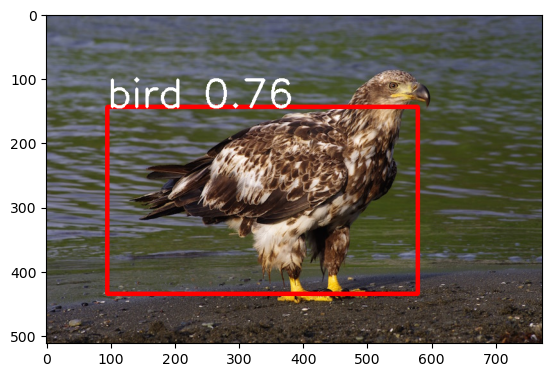

In [133]:
# All at one place
modelConf="yolov3-tiny.cfg"
modelWeights="yolov3-tiny.weights"
classesFile="coco.names"
image='./images/eagle.jpg'
def yolo_out(modelConf,modelWeights,classesFile,image):
    net = cv2.dnn.readNetFromDarknet(modelConf,modelWeights)
    with open(classesFile,'rt') as f:
        classes = f.read().rstrip('\n').split('\n')

    inpWidth = 416
    inpHeight = 416

    frame=cv2.imread(image)
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 

    blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], 1, crop = False) # pass the image
    net.setInput(blob)
    yolo_layers=net.getUnconnectedOutLayersNames()
    outs = net.forward(yolo_layers)
    post_process(frame,outs,img,classes)

yolo_out(modelConf,modelWeights,classesFile,image)

https://docs.ultralytics.com/quickstart/#use-ultralytics-with-python

# Set up the input

    - Model variable name : net
    - image name : blob
    - method name : setInput

In [113]:
net.setInput(blob)

# for the yolo arch , we cant pass direct image
# we are converting image into blob

# Process flow
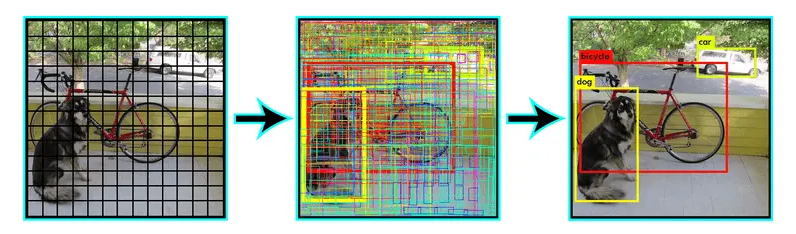

1. You look only once
2. It is a pretrained model
3. Configuration and weights
4. Yolo input image size : 416 x 416
5. The number of classes are 80
6. Blob from image
   - A) image resize
   - B) convert BGR to RGB
   - C) Normalization
   - D) 4D (batch size, channel, height, width)
7. The image will pass toYOLO unconnected layers
8. It will give the multiple bounding boxes for each image
9. Each box has 85 values
    - A) First four values x,y,w,h
    - B) 5th value is Confidence
    - C) Last 80 values probability of each class
10. We need to iterate through each box vector and we need to filter out the boxes which are probability greater

**confidence score**
index no.5
    - How much model confident in such a way there is an object available
    - So many boxes does not capture the image
    - So we can filter it out using confidence

**probability score**
    - The probability that the particular object belongs to which class
    - Max probability means model identified the object of a particular class

**Final score**
    - Confidence_score * max_probability

# Confidence Score :

index no.5
- How much model confident in such a way there is an object available
- So many boxes does not capture the image
- So we can filter it out using confidence

# probability score :

- It the probability the particular object belongs to which class

- Max probability means model identified the object of a particular class

# Final Score :

- Confidence_score * max_probability

In [ ]:
## Pass the image through YOLO layers

In [131]:
out1=[[1,2,3,4],['A','B','C','D']]
out2=[[11,22,33,44],['AA','BB','CC','DD']]
outs=[out1,out2]
for i in outs:
    for j in i:
        print(j)

[1, 2, 3, 4]
['A', 'B', 'C', 'D']
[11, 22, 33, 44]
['AA', 'BB', 'CC', 'DD']
